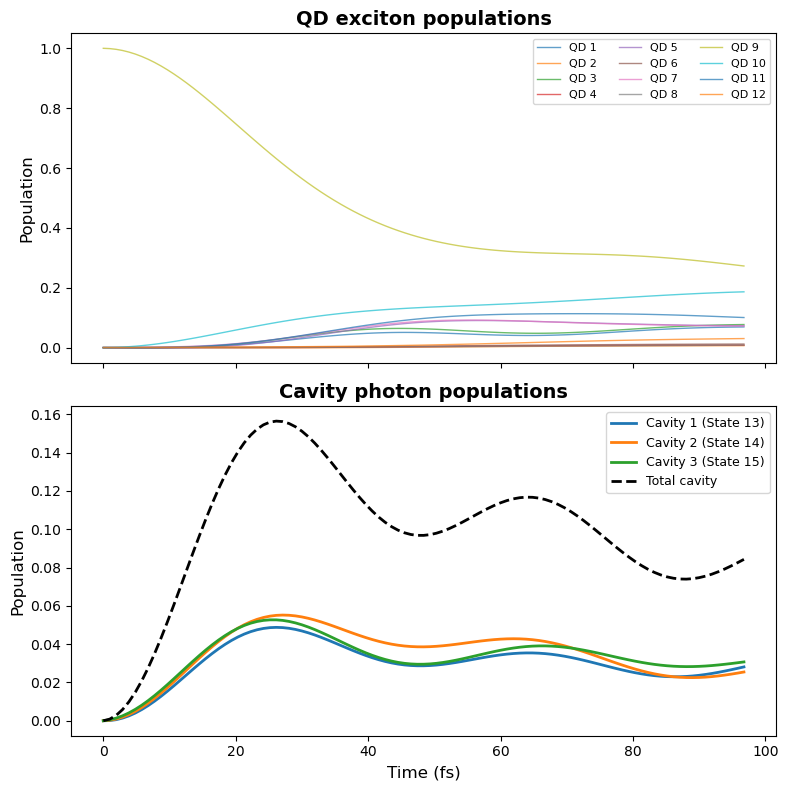

Max cavity populations:
  Cavity 1: 0.048766
  Cavity 2: 0.0551906
  Cavity 3: 0.0526951
  Total cavity: 0.156495


In [1]:
#!/usr/bin/env python3
"""
Read and plot population data from pop.out.

State ordering for this TC example:
- States 1-12: QD exciton states
- States 13-15: cavity photon states
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
n_qd = 6
nstate_per_qd = 2
n_cavity = 3
n_qd_states = n_qd * nstate_per_qd

data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
populations = data[:, 1:]
n_states = populations.shape[1]

if n_states != n_qd_states + n_cavity:
    raise ValueError(f"Expected {n_qd_states + n_cavity} states, found {n_states}")

qd_pop = populations[:, :n_qd_states]
cavity_pop = populations[:, n_qd_states:]

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for state in range(n_qd_states):
    axes[0].plot(time, qd_pop[:, state], label=f"QD {state + 1}", linewidth=1, alpha=0.7)
axes[0].set_ylabel("Population", fontsize=12)
axes[0].set_title("QD exciton populations", fontsize=14, fontweight="bold")
axes[0].legend(ncol=3, fontsize=8)

for cav in range(n_cavity):
    axes[1].plot(time, cavity_pop[:, cav], label=f"Cavity {cav + 1} (State {n_qd_states + cav + 1})", linewidth=2)
axes[1].plot(time, cavity_pop.sum(axis=1), "k--", label="Total cavity", linewidth=2)
axes[1].set_xlabel("Time (fs)", fontsize=12)
axes[1].set_ylabel("Population", fontsize=12)
axes[1].set_title("Cavity photon populations", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Max cavity populations:")
for cav in range(n_cavity):
    print(f"  Cavity {cav + 1}: {cavity_pop[:, cav].max():.6g}")
print(f"  Total cavity: {cavity_pop.sum(axis=1).max():.6g}")

